Submitted by Arnav Aditya, Roll no. 2210110189

#Question (10 marks total). You have the boilerplate image-captioning code from previous lab. Perform the tasks below and submit: (i) modified code files or diff, results and answers. Label your answers (a)–(d).

#(a) Implement soft attention and show alpha sums = 1 for a batch. (5 marks)
Paper: Show, Attend and Tell (Xu et al., 2015)[https://arxiv.org/pdf/1502.03044]
Perform training and evaluation separately as per previous lab.

#(b) Visualize attention maps for 5 test images and comment. (5 marks)

In [1]:
# (Optional) Colab/Ubuntu dependency for git-lfs support when downloading datasets
!apt-get install -y git-lfs

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [2]:
# Flickr8k from the Keras example / jbrownlee mirror (works in Colab / Linux environments)
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip
!unzip -qq Flickr8k_Dataset.zip
!unzip -qq Flickr8k_text.zip
!rm Flickr8k_Dataset.zip Flickr8k_text.zip

In [3]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
import glob
import os
import random
import re
from collections import Counter
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
import torchvision.transforms as T
from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu
from nltk.translate.meteor_score import meteor_score

In [5]:
# ----------------- Hyperparameters -----------------
EMBED_SIZE = 256
HIDDEN_SIZE = 512
ATTN_DIM = 256
NUM_LAYERS = 1
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 6  # adjustable; use a small number for demos
MAX_SEQ_LEN = 20
MIN_WORD_FREQ = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [6]:
# ----------------- Vocabulary builder -----------------
class Vocabulary:
    def __init__(self, freq_threshold: int = MIN_WORD_FREQ):
        self.freq_threshold = freq_threshold
        self.word2idx: Dict[str, int] = {"<pad>": 0, "<start>": 1, "<end>": 2, "<unk>": 3}
        self.idx2word: Dict[int, str] = {idx: token for token, idx in self.word2idx.items()}
        self.freqs = Counter()
        self.next_idx = 4
    def tokenize(self, text: str) -> List[str]:
        text = text.lower()
        tokens = re.findall(r"\w+", text)
        return tokens
    def build_vocab(self, captions_list: List[str]) -> None:
        for caption in captions_list:
            tokens = self.tokenize(caption)
            self.freqs.update(tokens)
        for word, cnt in self.freqs.items():
            if cnt >= self.freq_threshold and word not in self.word2idx:
                self.word2idx[word] = self.next_idx
                self.idx2word[self.next_idx] = word
                self.next_idx += 1
    def numericalize(self, text: str) -> List[int]:
        tokens = self.tokenize(text)
        return [self.word2idx.get(tok, self.word2idx["<unk>"]) for tok in tokens]

In [7]:
# ----------------- Dataset and collate utilities -----------------
class FlickrDataset(Dataset):
    def __init__(self, images_dir: str, captions_file: str, vocab: Vocabulary, transform=None, max_len: int = MAX_SEQ_LEN):
        self.images_dir = images_dir
        self.captions_file = captions_file
        self.vocab = vocab
        self.transform = transform
        self.max_len = max_len
        if not os.path.exists(self.images_dir):
            raise FileNotFoundError(f"Images directory not found: {self.images_dir}")
        if not os.path.exists(self.captions_file):
            raise FileNotFoundError(f"Captions file not found: {self.captions_file}")
        self.img_caps: Dict[str, List[str]] = {}
        with open(self.captions_file, "r", encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                parts = line.split("\t")
                if len(parts) != 2:
                    continue
                img_id, caption = parts
                img_id = img_id.split("#")[0]
                self.img_caps.setdefault(img_id, []).append(caption)
        if not self.img_caps:
            raise RuntimeError("No captions parsed from file.")
        candidate_ids = sorted(self.img_caps.keys())
        self.image_ids: List[str] = []
        for imgname in candidate_ids:
            resolved = self._resolve_image_path(imgname)
            if resolved is None:
                continue
            if self._is_image_valid(resolved):
                self.image_ids.append(imgname)
        if not self.image_ids:
            raise RuntimeError("No valid images found in dataset.")
    @staticmethod
    def _is_image_valid(img_path: str) -> bool:
        try:
            with Image.open(img_path) as img:
                img.verify()
            return True
        except (UnidentifiedImageError, OSError):
            return False
    def _resolve_image_path(self, imgname: str):
        imgpath = os.path.join(self.images_dir, imgname)
        if os.path.exists(imgpath):
            return imgpath
        base, _ = os.path.splitext(imgname)
        fallback = base + ".jpg"
        candidates = [
            os.path.join(self.images_dir, fallback),
            *glob.glob(os.path.join(self.images_dir, base + ".*"))
        ]
        for cand in candidates:
            if os.path.exists(cand):
                return cand
        return None
    def __len__(self) -> int:
        return len(self.image_ids)
    def __getitem__(self, idx: int):
        imgname = self.image_ids[idx]
        imgpath = self._resolve_image_path(imgname)
        if imgpath is None or not os.path.exists(imgpath):
            raise FileNotFoundError(f"{imgname} not found in {self.images_dir}")
        img = Image.open(imgpath).convert("RGB")
        img_t = self.transform(img) if self.transform else T.ToTensor()(img)
        captions = self.img_caps[imgname]
        caption = random.choice(captions)
        tokens = [self.vocab.word2idx["<start>"]] + self.vocab.numericalize(caption) + [self.vocab.word2idx["<end>"]]
        if len(tokens) > self.max_len:
            tokens = tokens[:self.max_len]
            tokens[-1] = self.vocab.word2idx["<end>"]
        caption_tensor = torch.tensor(tokens, dtype=torch.long)
        return img_t, caption_tensor, imgname
def collate_fn(batch):
    imgs, caps, names = zip(*batch)
    imgs = torch.stack(imgs)
    lengths = [len(c) for c in caps]
    max_len = max(lengths)
    padded = torch.zeros(len(caps), max_len, dtype=torch.long)
    for i, cap in enumerate(caps):
        padded[i, :len(cap)] = cap
    return imgs, padded, lengths, names

In [8]:
# ----------------- Encoder with spatial features -----------------
class ResNetAttentionEncoder(nn.Module):
    def __init__(self, embed_size: int = EMBED_SIZE, pretrained: bool = True, finetune: bool = False, enc_image_size: int = 14):
        super().__init__()
        self.enc_image_size = enc_image_size
        try:
            weights = models.ResNet50_Weights.DEFAULT if pretrained else None
            backbone = models.resnet50(weights=weights)
        except AttributeError:
            backbone = models.resnet50(pretrained=pretrained)
        modules = list(backbone.children())[:-2]
        self.backbone = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((enc_image_size, enc_image_size))
        self.conv = nn.Conv2d(backbone.fc.in_features, embed_size, kernel_size=1)
        self.finetune(finetune)
        nn.init.xavier_uniform_(self.conv.weight)
        nn.init.zeros_(self.conv.bias)
    def finetune(self, enable: bool = True) -> None:
        for param in self.backbone.parameters():
            param.requires_grad = enable
    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.backbone(images)
        features = self.adaptive_pool(features)
        features = self.conv(features)
        features = features.permute(0, 2, 3, 1)
        batch_size, feat_h, feat_w, feat_dim = features.size()
        features = features.view(batch_size, -1, feat_dim)
        return features

In [9]:
# ----------------- Attention-based decoder -----------------
class Attention(nn.Module):
    def __init__(self, encoder_dim: int, decoder_dim: int, attention_dim: int):
        super().__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
    def forward(self, encoder_out: torch.Tensor, decoder_hidden: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden).unsqueeze(1)
        att = self.full_att(self.relu(att1 + att2)).squeeze(2)
        alpha = self.softmax(att)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha
class DecoderWithAttention(nn.Module):
    def __init__(self, embed_size: int, hidden_size: int, vocab_size: int, num_layers: int = 1, attention_dim: int = ATTN_DIM, encoder_dim: int = EMBED_SIZE, dropout: float = 0.5):
        super().__init__()
        self.vocab_size = vocab_size
        self.encoder_dim = encoder_dim
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.decode_step = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.f_beta = nn.Linear(hidden_size, encoder_dim)
        self.sigmoid = nn.Sigmoid()
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.init_weights()
    def init_weights(self) -> None:
        nn.init.uniform_(self.embed.weight, -0.1, 0.1)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)
    def init_hidden_state(self, encoder_out: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        mean_encoder = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder)
        c = self.init_c(mean_encoder)
        return h, c
    def forward(self, encoder_out: torch.Tensor, captions: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        embeddings = self.embed(captions)
        batch_size = encoder_out.size(0)
        num_pixels = encoder_out.size(1)
        seq_len = captions.size(1)
        predictions = torch.zeros(batch_size, seq_len, self.vocab_size, device=encoder_out.device)
        alphas = torch.zeros(batch_size, seq_len, num_pixels, device=encoder_out.device)
        h, c = self.init_hidden_state(encoder_out)
        for t in range(seq_len):
            context, alpha = self.attention(encoder_out, h)
            gate = self.sigmoid(self.f_beta(h))
            context = gate * context
            lstm_input = torch.cat([embeddings[:, t, :], context], dim=1)
            h, c = self.decode_step(lstm_input, (h, c))
            preds = self.fc(self.dropout(h))
            predictions[:, t, :] = preds
            alphas[:, t, :] = alpha
        return predictions, alphas
    def sample(self, encoder_out: torch.Tensor, vocab: Vocabulary, max_len: int = MAX_SEQ_LEN):
        batch_size = encoder_out.size(0)
        num_pixels = encoder_out.size(1)
        h, c = self.init_hidden_state(encoder_out)
        inputs = torch.full((batch_size,), vocab.word2idx["<start>"], dtype=torch.long, device=encoder_out.device)
        sampled_ids = []
        collected_alphas = []
        for _ in range(max_len):
            embeddings = self.embed(inputs)
            context, alpha = self.attention(encoder_out, h)
            gate = self.sigmoid(self.f_beta(h))
            context = gate * context
            h, c = self.decode_step(torch.cat([embeddings, context], dim=1), (h, c))
            outputs = self.fc(self.dropout(h))
            predicted = outputs.argmax(dim=1)
            sampled_ids.append(predicted.unsqueeze(1))
            collected_alphas.append(alpha.unsqueeze(1))
            inputs = predicted
        sampled_ids = torch.cat(sampled_ids, dim=1)
        collected_alphas = torch.cat(collected_alphas, dim=1)
        return sampled_ids, collected_alphas

In [10]:
# ----------------- Helper utilities -----------------
def idxs_to_sentence(idxs: List[int], vocab: Vocabulary) -> str:
    words = []
    for idx in idxs:
        word = vocab.idx2word.get(int(idx), "<unk>")
        if word == "<end>":
            break
        if word not in {"<start>", "<pad>"}:
            words.append(word)
    return " ".join(words)
def denormalize_image(tensor: torch.Tensor) -> np.ndarray:
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

In [11]:
# ----------------- Training and evaluation helpers -----------------
def build_vocab_from_file(captions_txt: str) -> Vocabulary:
    captions = []
    with open(captions_txt, "r", encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            captions.append(line.split("\t")[1])
    vocab = Vocabulary(freq_threshold=MIN_WORD_FREQ)
    vocab.build_vocab(captions)
    print("Vocab size:", len(vocab.word2idx))
    return vocab
def create_dataloader(images_dir: str, captions_txt: str, vocab: Vocabulary, batch_size: int = BATCH_SIZE, shuffle: bool = True):
    transform = T.Compose([
        T.Resize((256, 256)),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    dataset = FlickrDataset(images_dir, captions_txt, vocab, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)
    return dataset, loader
def train_attention_model(images_dir: str, captions_txt: str, epochs: int = EPOCHS, finetune_encoder: bool = False, save_tag: str = "resnet50_attn_lstm"):
    vocab = build_vocab_from_file(captions_txt)
    dataset, dataloader = create_dataloader(images_dir, captions_txt, vocab)
    encoder = ResNetAttentionEncoder(embed_size=EMBED_SIZE, pretrained=True, finetune=finetune_encoder).to(DEVICE)
    decoder = DecoderWithAttention(EMBED_SIZE, HIDDEN_SIZE, len(vocab.word2idx), NUM_LAYERS, ATTN_DIM).to(DEVICE)
    criterion = nn.CrossEntropyLoss(ignore_index=vocab.word2idx["<pad>"])
    params = list(filter(lambda p: p.requires_grad, encoder.parameters())) + list(decoder.parameters())
    optimizer = optim.Adam(params, lr=LR)
    history = []
    for epoch in range(epochs):
        encoder.train(); decoder.train()
        total_loss = 0.0
        for imgs, caps, lengths, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs = imgs.to(DEVICE)
            caps = caps.to(DEVICE)
            targets = caps[:, 1:]
            decoder_inputs = caps[:, :-1]
            encoder_out = encoder(imgs)
            outputs, alphas = decoder(encoder_out, decoder_inputs)
            outputs = outputs.view(-1, outputs.size(2))
            targets = targets.contiguous().view(-1)
            loss = criterion(outputs, targets)
            loss += 1.0 * ((alphas.sum(dim=2) - 1.0) ** 2).mean()
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 5.0)
            optimizer.step()
            total_loss += loss.item()
        epoch_loss = total_loss / len(dataloader)
        history.append(epoch_loss)
        print(f"Epoch {epoch+1} loss: {epoch_loss:.4f}")
    save_path = f"attention_model_{save_tag}.pth"
    torch.save({
        'encoder': encoder.state_dict(),
        'decoder': decoder.state_dict(),
        'vocab': vocab.word2idx
    }, save_path)
    print(f"Saved {save_path}")
    return {
        'encoder': encoder,
        'decoder': decoder,
        'vocab': vocab,
        'dataset': dataset,
        'dataloader': dataloader,
        'history': history,
        'save_path': save_path
    }

In [12]:
def compute_metrics(encoder: nn.Module, decoder: nn.Module, vocab: Vocabulary, dataset: FlickrDataset, batches: int = 10, batch_size: int = 32):
    encoder.eval(); decoder.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    refs_all = []
    hyps_all = []
    smooth = SmoothingFunction().method1
    with torch.no_grad():
        for idx, (imgs, caps, lengths, names) in enumerate(loader):
            if idx >= batches:
                break
            imgs = imgs.to(DEVICE)
            encoder_out = encoder(imgs)
            sampled, _ = decoder.sample(encoder_out, vocab)
            sampled = sampled.cpu().numpy()
            for j in range(sampled.shape[0]):
                pred_tokens = idxs_to_sentence(sampled[j], vocab).split()
                hyps_all.append(pred_tokens)
                refs = [nltk.word_tokenize(r.lower()) for r in dataset.img_caps[names[j]]]
                refs_all.append(refs)
    if not hyps_all:
        return {'BLEU-1': 0.0, 'BLEU-4': 0.0, 'METEOR': 0.0}
    bleu1 = np.mean([sentence_bleu(refs_all[i], hyps_all[i], weights=(1,0,0,0), smoothing_function=smooth) for i in range(len(hyps_all))])
    bleu4 = np.mean([sentence_bleu(refs_all[i], hyps_all[i], weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth) for i in range(len(hyps_all))])
    meteor = np.mean([meteor_score(refs_all[i], hyps_all[i]) for i in range(len(hyps_all))])
    return {'BLEU-1': bleu1, 'BLEU-4': bleu4, 'METEOR': meteor}
def load_attention_checkpoint(checkpoint_path: str):
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    vocab = Vocabulary()
    vocab.word2idx = dict(ckpt['vocab'])
    vocab.idx2word = {idx: tok for tok, idx in vocab.word2idx.items()}
    vocab.next_idx = max(vocab.idx2word.keys()) + 1
    encoder = ResNetAttentionEncoder(embed_size=EMBED_SIZE, pretrained=False).to(DEVICE)
    decoder = DecoderWithAttention(EMBED_SIZE, HIDDEN_SIZE, len(vocab.word2idx), NUM_LAYERS, ATTN_DIM).to(DEVICE)
    encoder.load_state_dict(ckpt['encoder'])
    decoder.load_state_dict(ckpt['decoder'])
    encoder.eval(); decoder.eval()
    return encoder, decoder, vocab

In [13]:
def show_alpha_sums(encoder: nn.Module, decoder: nn.Module, dataloader: DataLoader, vocab: Vocabulary, steps: int = 1):
    encoder.eval(); decoder.eval()
    iterator = iter(dataloader)
    with torch.no_grad():
        for _ in range(steps):
            imgs, caps, lengths, names = next(iterator)
            imgs = imgs.to(DEVICE)
            caps = caps.to(DEVICE)
            encoder_out = encoder(imgs)
            outputs, alphas = decoder(encoder_out, caps[:, :-1])
            alpha_sums = alphas.sum(dim=2).cpu().numpy()
            print("Alpha sums (should be ~1.0) for batch:")
            for i in range(min(len(names), 3)):
                valid_steps = lengths[i] - 1
                row = alpha_sums[i, :valid_steps]
                print(f"{names[i]} ->", np.round(row, 4))
            break

In [14]:
def visualize_attention(image_path: str, tokens: List[str], alphas: np.ndarray, enc_image_size: int) -> None:
    if len(tokens) == 0:
        print("No tokens to visualize.")
        return
    image = Image.open(image_path).convert("RGB")
    cols = 5
    rows = int(np.ceil(len(tokens) / cols))
    plt.figure(figsize=(cols * 3, rows * 3))
    for idx, token in enumerate(tokens):
        ax = plt.subplot(rows, cols, idx + 1)
        ax.imshow(image)
        attention_map = alphas[idx].reshape(enc_image_size, enc_image_size)
        if attention_map.max() > 0:
            attention_map = attention_map / attention_map.max()
        ax.imshow(attention_map, cmap='jet', alpha=0.35, extent=(0, image.size[0], image.size[1], 0))
        ax.set_title(token)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [15]:
# Paths to Flickr8k data
IMAGES_DIR = "/content/Flicker8k_Dataset"
CAPTIONS_FILE = "Flickr8k.token.txt"

In [21]:
# Part (a): train attention-equipped captioner
attention_results = train_attention_model(
    IMAGES_DIR,
    CAPTIONS_FILE,
    epochs=10,
    finetune_encoder=False,
    save_tag="resnet50_attn_lstm_e3"
)

Vocab size: 2982


Epoch 1/10: 100%|██████████| 127/127 [01:21<00:00,  1.55it/s]


Epoch 1 loss: 5.1801


Epoch 2/10: 100%|██████████| 127/127 [01:21<00:00,  1.56it/s]


Epoch 2 loss: 4.4001


...

Epoch 8 loss: 3.1120


Epoch 9/10: 100%|██████████| 127/127 [01:24<00:00,  1.50it/s]


Epoch 9 loss: 3.0586


Epoch 10/10: 100%|██████████| 127/127 [01:20<00:00,  1.57it/s]


Epoch 10 loss: 2.9974
Saved attention_model_resnet50_attn_lstm_e3.pth


In [22]:
# Part (a): verify attention weights sum to 1 per time step
show_alpha_sums(
    attention_results['encoder'],
    attention_results['decoder'],
    attention_results['dataloader'],
    attention_results['vocab']
 )

Alpha sums (should be ~1.0) for batch:
2992658871_ac786d37a6.jpg -> [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
3259992638_0612a40288.jpg -> [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
3142055158_01b9e4caa4.jpg -> [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [23]:
# Evaluate quantitative metrics on a validation subset
attention_metrics = compute_metrics(
    attention_results['encoder'],
    attention_results['decoder'],
    attention_results['vocab'],
    attention_results['dataset'],
    batches=10,
    batch_size=32
)
attention_metrics

{'BLEU-1': np.float64(0.5639865414051316),
 'BLEU-4': np.float64(0.15555403265177917),
 'METEOR': np.float64(0.35156155208320883)}

### Quantitative Metrics
Record BLEU-1, BLEU-4, and METEOR from the previous cell here once you run the notebook.

In [24]:
def visualize_batch_attention(encoder: ResNetAttentionEncoder, decoder: DecoderWithAttention, vocab: Vocabulary, dataset: FlickrDataset, num_images: int = 5, max_tokens: int = 12):
    encoder.eval(); decoder.eval()
    sampler = DataLoader(dataset, batch_size=num_images, shuffle=True, collate_fn=collate_fn)
    imgs, caps, lengths, names = next(iter(sampler))
    imgs = imgs.to(DEVICE)
    with torch.no_grad():
        encoder_out = encoder(imgs)
        sampled, attn = decoder.sample(encoder_out, vocab, max_len=max_tokens)
    sampled = sampled.cpu().numpy()
    attn = attn.cpu().numpy()
    for idx in range(min(num_images, sampled.shape[0])):
        tokens = []
        for token_id in sampled[idx]:
            word = vocab.idx2word.get(int(token_id), "<unk>")
            if word == "<end>":
                break
            if word not in {"<start>", "<pad>"}:
                tokens.append(word)
        img_path = dataset._resolve_image_path(names[idx])
        if not tokens:
            print(f"{names[idx]} -> no valid tokens generated.")
            continue
        print(f"Image: {names[idx]}")
        print("Caption:", " ".join(tokens))
        visualize_attention(img_path, tokens, attn[idx, :len(tokens)], encoder.enc_image_size)

Image: 522486784_978021d537.jpg
Caption: a dog is running on a grassy path


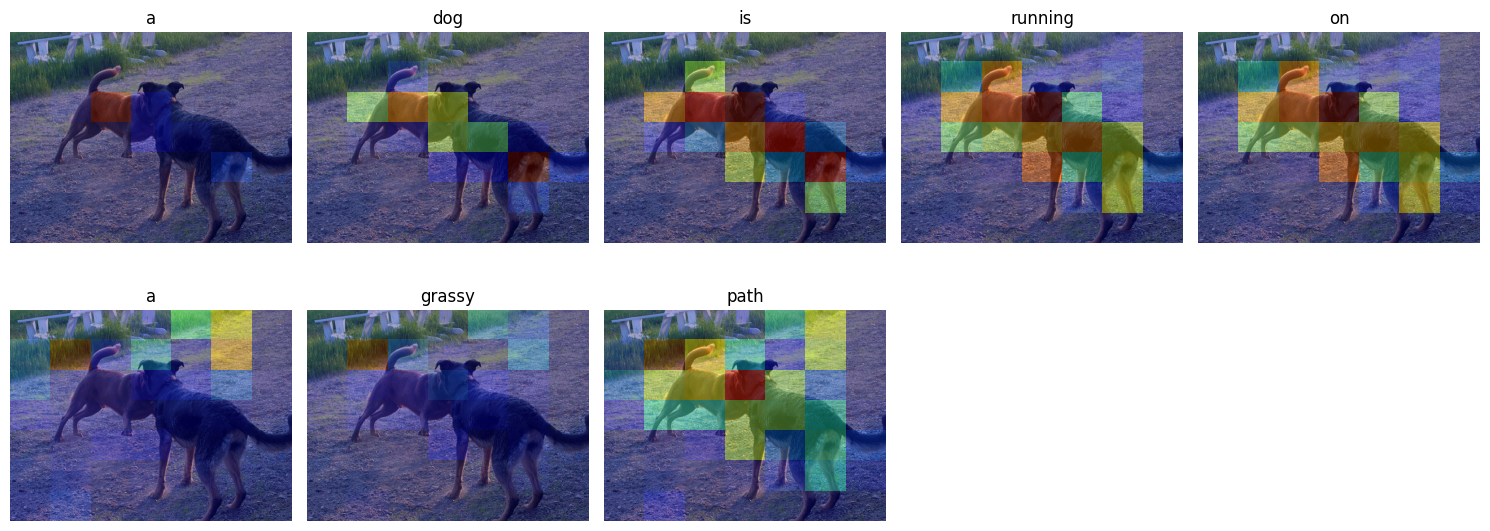

Image: 427082246_5bf1c3676f.jpg
Caption: a boy in a red shirt is running on a field


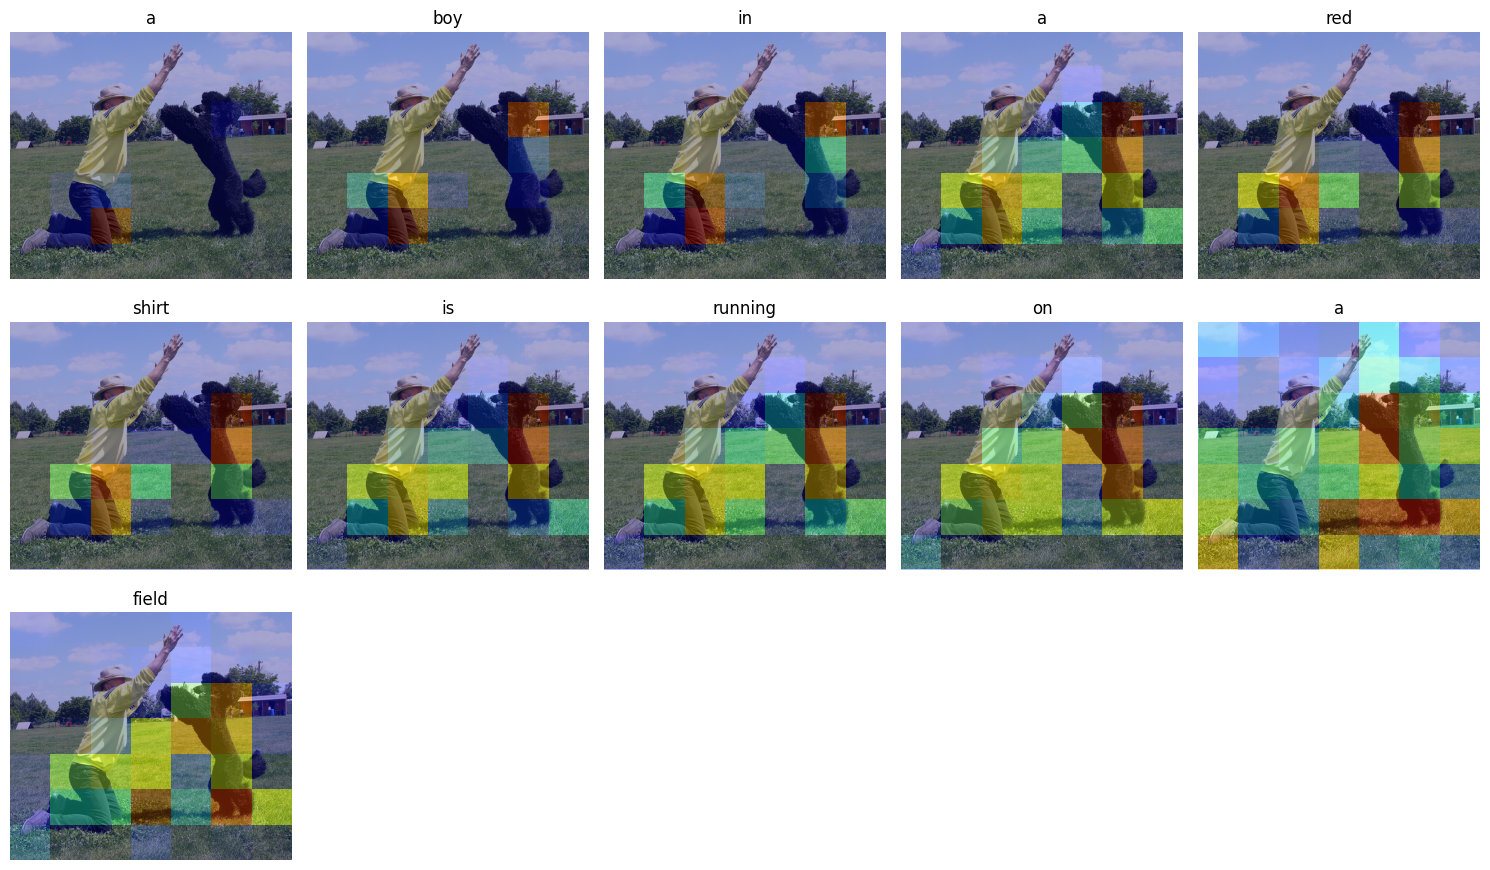

Image: 367964525_b1528ac6e4.jpg
Caption: a dog is running through the snow


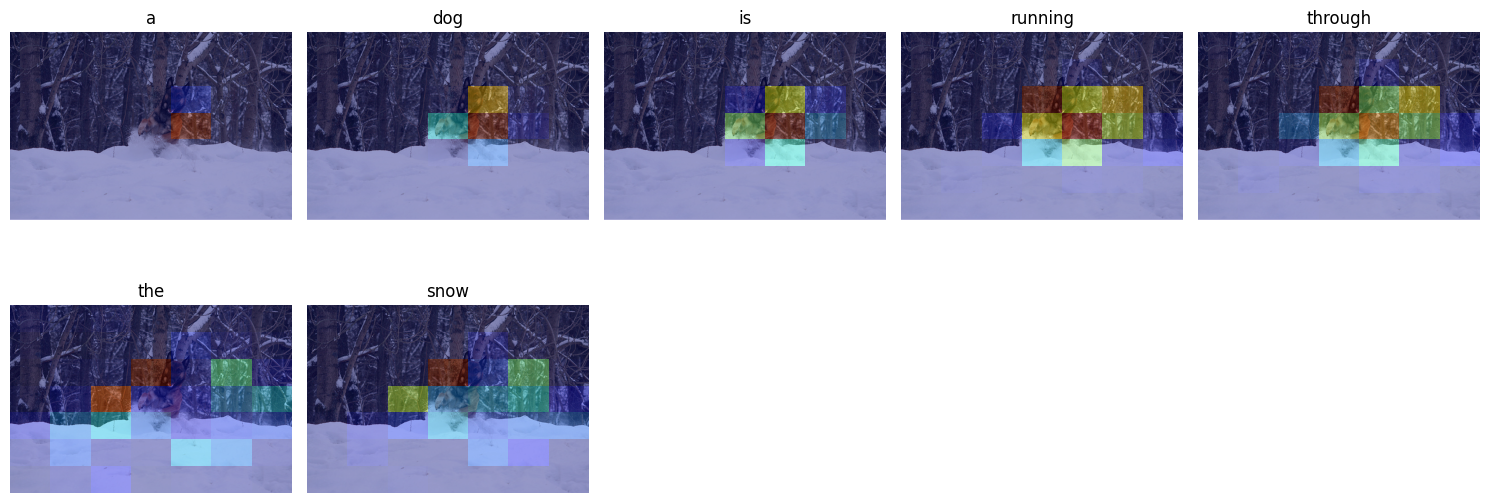

Image: 607339469_af851c4119.jpg
Caption: a little girl is sitting on a rock swing


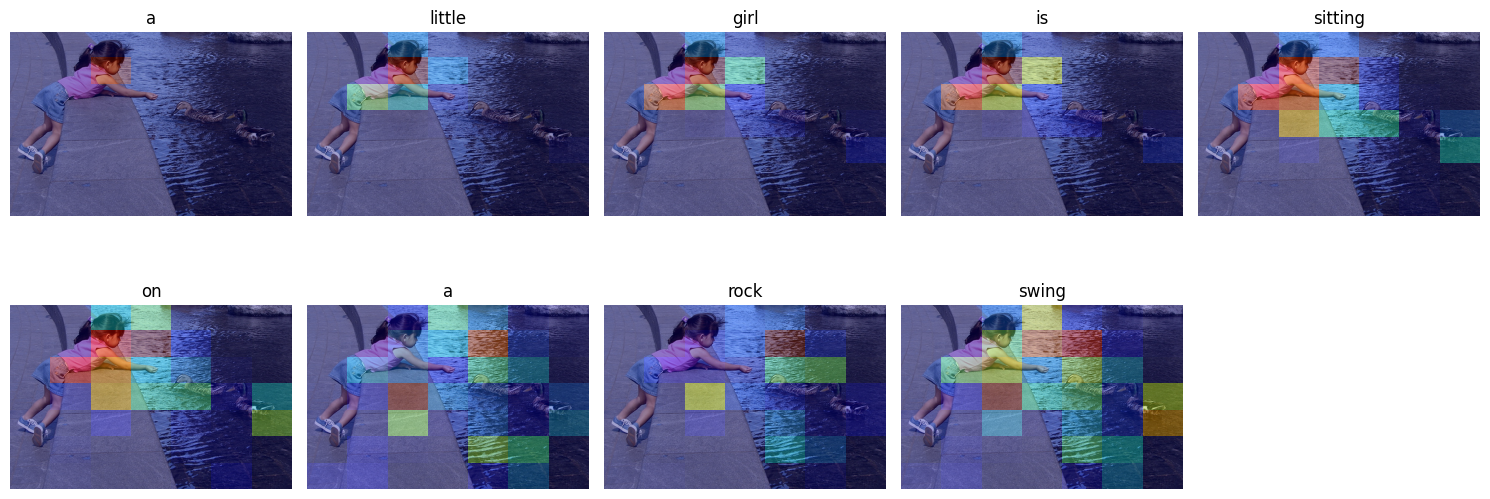

Image: 3248752274_96740ed073.jpg
Caption: a dog is standing on a snowy hill


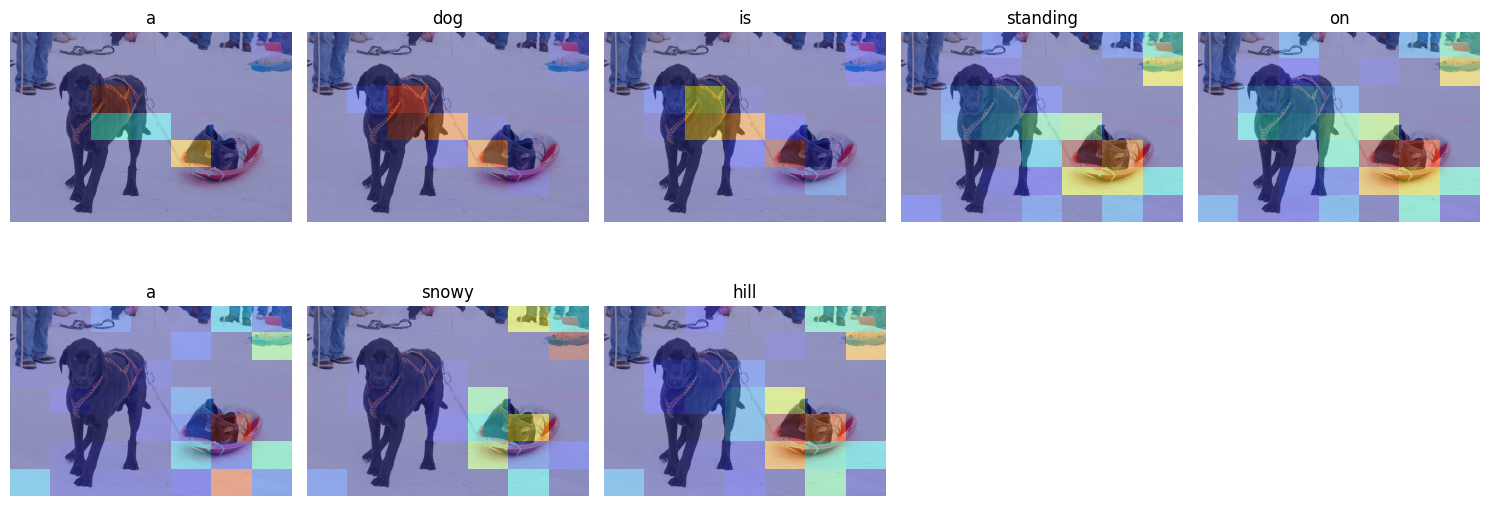

In [25]:
# Part (b): visualize attention maps for five sampled images
visualize_batch_attention(
    attention_results['encoder'],
    attention_results['decoder'],
    attention_results['vocab'],
    attention_results['dataset'],
    num_images=5,
    max_tokens=12
)